# Titanic passenger survival

A compact exploratory analysis and baseline model using Seaborn's 891 passenger Titanic dataset. The data is incomplete, and observed associations are not causal explanations.

Workflow: inspect data, explore survival rates, then compare a logistic-regression model with a majority-class baseline on held-out passengers.

## 1. Load the data

Requires pandas, numpy, seaborn, matplotlib, and scikit-learn. Seaborn may need an internet connection to download its sample dataset the first time.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
titanic = sns.load_dataset("titanic")
print(f"{len(titanic)} passengers, {len(titanic.columns)} columns")
titanic.head()

891 passengers, 15 columns


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Check data quality

Review types, duplicate records, and missing values before analysis. Age, embarked port, and deck contain missing entries in this teaching dataset.

In [2]:
titanic.info()
print(f"\nDuplicate rows: {titanic.duplicated().sum()}")
missing = titanic.isna().sum().rename("missing").to_frame()
missing["percent"] = (100 * missing["missing"] / len(titanic)).round(1)
missing.query("missing > 0").sort_values("missing", ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Duplicate rows: 107


,missing,percent
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2


## 3. Explore survival patterns

These are descriptive comparisons in this sample; passenger characteristics overlap, so group differences should not be interpreted as causal effects.

Overall survival rate: 38.4%


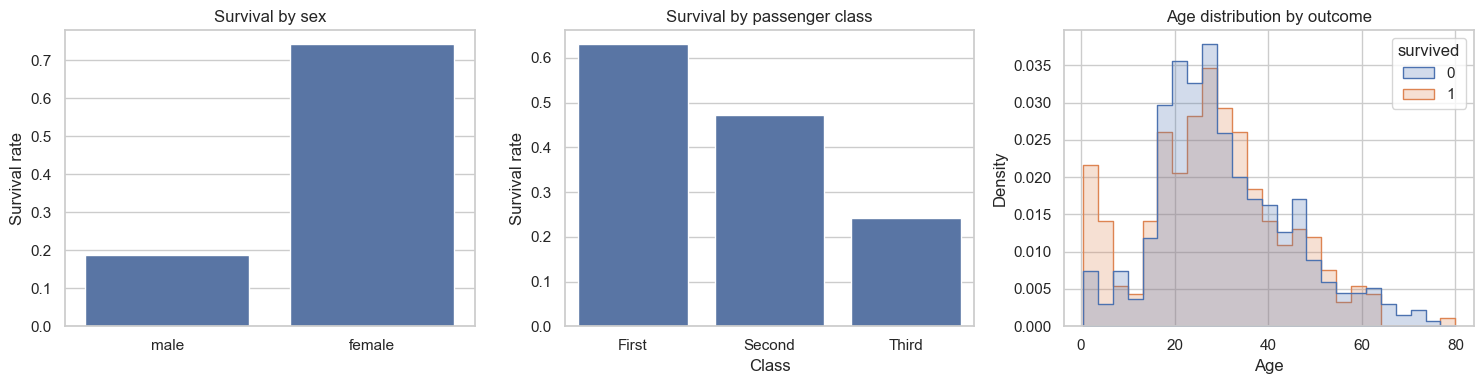

survival_rate  passengers
sex    class                            
female First           0.968          94
       Second          0.921          76
       Third           0.500         144
male   First           0.369         122
       Second          0.157         108
       Third           0.135         347

In [3]:
print(f"Overall survival rate: {titanic['survived'].mean():.1%}")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=titanic, x="sex", y="survived", errorbar=None, ax=axes[0])
axes[0].set(title="Survival by sex", xlabel="", ylabel="Survival rate")
sns.barplot(data=titanic, x="class", y="survived", order=["First", "Second", "Third"], errorbar=None, ax=axes[1])
axes[1].set(title="Survival by passenger class", xlabel="Class", ylabel="Survival rate")
sns.histplot(data=titanic, x="age", hue="survived", bins=25, element="step", stat="density", common_norm=False, ax=axes[2])
axes[2].set(title="Age distribution by outcome", xlabel="Age", ylabel="Density")
plt.tight_layout()
plt.show()
titanic.groupby(["sex", "class"], observed=True)["survived"].agg(survival_rate="mean", passengers="count").round(3)

## 4. Build and evaluate a baseline model

Use a stratified hold-out split. The preprocessing steps live inside the model pipeline, so imputers, scaling, and category encoding are learned from training rows only. The model uses a small set of passenger attributes and is evaluated once on unseen rows.

In [4]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X = titanic[features]
y = titanic["survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

numeric = ["pclass", "age", "sibsp", "parch", "fare"]
categorical = ["sex", "embarked"]
numeric_steps = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
category_steps = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encode", OneHotEncoder(handle_unknown="ignore"))])
preprocess = ColumnTransformer([("numeric", numeric_steps, numeric), ("categorical", category_steps, categorical)])
model = Pipeline([("preprocess", preprocess), ("classifier", LogisticRegression(max_iter=1000))])
model.fit(X_train, y_train)
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]
baseline = np.full(len(y_test), y_train.mode().iloc[0])
print(f"Train/test rows: {len(X_train)}/{len(X_test)}")
print(f"Majority-class accuracy: {accuracy_score(y_test, baseline):.3f}")
print(f"Model accuracy:          {accuracy_score(y_test, predictions):.3f}")
print(f"Model ROC AUC:           {roc_auc_score(y_test, probabilities):.3f}")
print()
print(classification_report(y_test, predictions, target_names=["Did not survive", "Survived"], zero_division=0))

Train/test rows: 712/179
Majority-class accuracy: 0.615
Model accuracy:          0.804
Model ROC AUC:           0.844

                 precision    recall  f1-score   support

Did not survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



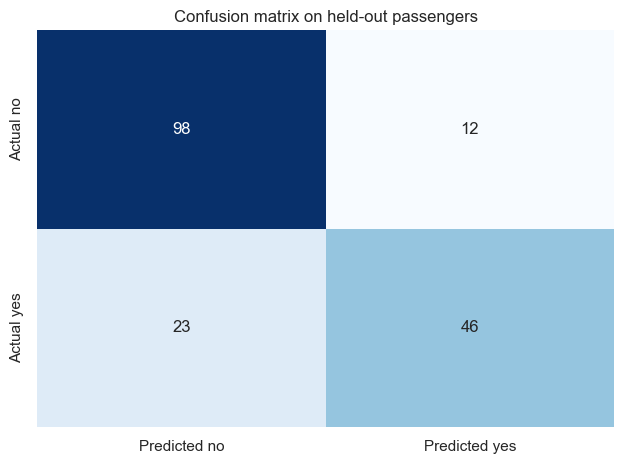

In [5]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Predicted no", "Predicted yes"], yticklabels=["Actual no", "Actual yes"])
plt.title("Confusion matrix on held-out passengers")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 5. Interpretation and limitations

Compare the model with the majority-class baseline; accuracy can obscure errors in one class, so review the classification report and ROC AUC as well. This is a small historical sample and a single split, so scores can vary with the split and feature choices. The results are not causal claims or a reliable tool for decisions about people. For a competition submission or stronger performance estimate, use the official files and cross-validation, keeping final test data untouched.